<a href="https://colab.research.google.com/github/fauzanghazi/advanced-ai/blob/main/MRTB2153_PMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

_Universiti Teknologi Malaysia_
# 📕 Post Module Assessment (PMA)

**Programme**: MSc in Business Intelligence & Analytics  
**Course**: Advanced Artificial Intelligence (MRTB2153)  
**Lecturer**: Dr. Mohd Syahid bin Mohd Anuar  
**Student Name**: Ahmad Fauzan bin Mohd Ghazi (MRT234008)  

#### **Custom Deep Learning Solutions with Comparative Analysis**


*   Image Classification
*   Object Detection


## Step 1: Accessing Kaggle Dataset with Secret Key

Instead of uploading the `kaggle.json` manually, I used my Kaggle username and API key directly in Colab to authenticate and download the dataset. This makes the process faster and easier to replicate across runs.

I selected the **Vehicle Dataset for YOLO** from Kaggle because it includes both **image-level class labels** and **bounding box annotations** in YOLO format. This dual functionality makes it suitable for training models for both **image classification** and **object detection** within a single dataset, fulfilling the requirements of this PMA.

The dataset is clean, recently updated, and annotated across multiple vehicle classes such as cars, trucks, and buses. It also follows the YOLO-compatible structure, allowing direct integration with YOLOv11 and other deep learning models.

**Real-World Scenario:**  
This project simulates a **smart traffic surveillance system**, where a camera can identify and locate different types of vehicles in real-time. Such systems are applicable in:
- Urban traffic monitoring
- Toll collection automation
- Parking lot management
- Fleet analytics and logistics

By training both classification and object detection models, we demonstrate the pipeline required for intelligent vehicle recognition systems in smart cities.


In [1]:
import os
import json

# Replace these with your actual Kaggle credentials
kaggle_username = "KAGGLE_USERNAME"
kaggle_key = "KAGGLE_KEY"

# Save the credentials
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)

# Set permissions
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# Install Kaggle CLI
!pip install -q kaggle

# Download the dataset
!kaggle datasets download -d nadinpethiyagoda/vehicle-dataset-for-yolo

# Unzip
!unzip -q vehicle-dataset-for-yolo.zip -d vehicle_dataset

Dataset URL: https://www.kaggle.com/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo
License(s): DbCL-1.0
 70% 263M/375M [00:00<00:00, 1.37GB/s]
100% 375M/375M [00:00<00:00, 1.37GB/s]


## Step 2: Dataset Exploration and Sample Visualization

Before preprocessing, I explored the dataset structure to understand how the images and annotations are organized. This helps verify compatibility with image classification and object detection workflows. I also visualized sample images using `matplotlib.pyplot` to inspect the data quality and annotation consistency.

In [2]:
import os
import glob
from matplotlib import pyplot as plt
import cv2

# Set correct paths for train split
base_path = "vehicle_dataset/vehicle dataset"
train_image_dir = os.path.join(base_path, "train", "images")
train_label_dir = os.path.join(base_path, "train", "labels")

# Check number of samples
image_files = sorted(glob.glob(os.path.join(train_image_dir, "*.jpg")))
label_files = sorted(glob.glob(os.path.join(train_label_dir, "*.txt")))

print(f"Total images: {len(image_files)}")
print(f"Total labels: {len(label_files)}")

# Show a sample path
sample_image_path = image_files[0]
sample_label_path = label_files[0]

print("\nSample image path:", sample_image_path)
print("Sample label path:", sample_label_path)


Total images: 1435
Total labels: 2100

Sample image path: vehicle_dataset/vehicle dataset/train/images/00043_GMC Savana Van 2012.jpg
Sample label path: vehicle_dataset/vehicle dataset/train/labels/00043_GMC Savana Van 2012.txt


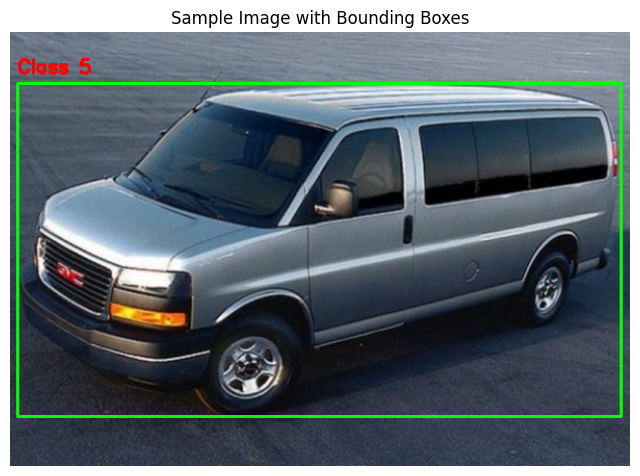

In [3]:
def load_yolo_labels(label_file):
    boxes = []
    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            cls, x_center, y_center, width, height = map(float, parts)
            boxes.append((int(cls), x_center, y_center, width, height))
    return boxes

def draw_boxes(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    boxes = load_yolo_labels(label_path)

    for cls_id, x_c, y_c, bw, bh in boxes:
        x1 = int((x_c - bw / 2) * w)
        y1 = int((y_c - bh / 2) * h)
        x2 = int((x_c + bw / 2) * w)
        y2 = int((y_c + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, f"Class {cls_id}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Sample Image with Bounding Boxes")
    plt.show()

# Draw the sample
draw_boxes(sample_image_path, sample_label_path)

## Step 3: Classification Preprocessing Adjustment

While extracting class labels from filenames, I discovered that not all images follow a consistent naming format. Only a subset includes brand or model names after an underscore. To ensure clean and meaningful labels for classification, I filtered the dataset to include only images with valid underscores, enabling consistent extraction of vehicle brand names.

During preprocessing, a ValueError was encountered due to some vehicle classes having only one sample. Since stratified splitting requires at least two samples per class, I further filtered out rare classes. This resulted in a clean and balanced dataset, suitable for training and testing with a stratified split.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

valid_data = []

for path in image_files:  # Changed from image_paths to image_files
    filename = os.path.basename(path)
    if "_" in filename:
        label = filename.split("_")[1]  # Safely extract label after "_"
        valid_data.append((path, label))

# Create initial DataFrame
df = pd.DataFrame(valid_data, columns=["image_path", "label"])
print("Unique labels before filtering:", df["label"].nunique())
print(df["label"].value_counts().head())

# Filter out labels with only 1 sample
df_filtered = df.groupby("label").filter(lambda x: len(x) > 1).reset_index(drop=True)

# Re-encode label IDs after filtering
df_filtered["label_id"] = df_filtered["label"].astype("category").cat.codes
label_map = dict(enumerate(df_filtered["label"].astype("category").cat.categories))
print(f"Filtered label count: {df_filtered['label'].nunique()}")
print("Updated label map:", label_map)

# Train-test split using filtered DataFrame
train_df, test_df = train_test_split(
    df_filtered, test_size=0.2, stratify=df_filtered["label_id"], random_state=42
)

print(f"Train samples: {len(train_df)} | Test samples: {len(test_df)}")

Unique labels before filtering: 600
label
Nissan NV Passenger Van 2012.jpg       13
Mercedes-Benz Sprinter Van 2012.jpg    12
GMC Savana Van 2012.jpg                12
                                        9
Chevrolet Express Van 2007.jpg          8
Name: count, dtype: int64
Filtered label count: 7
Updated label map: {0: '', 1: 'Chevrolet Express Cargo Van 2007.jpg', 2: 'Chevrolet Express Van 2007.jpg', 3: 'Ford E-Series Wagon Van 2012.jpg', 4: 'GMC Savana Van 2012.jpg', 5: 'Mercedes-Benz Sprinter Van 2012.jpg', 6: 'Nissan NV Passenger Van 2012.jpg'}
Train samples: 55 | Test samples: 14


## Step 4: Classification Model Implementation

For the image classification task, I implemented and compared three different convolutional neural network (CNN) architectures. The first is a custom CNN built from scratch to serve as a baseline. The second and third models utilize pretrained architectures (ResNet18 and MobileNetV2) with transfer learning. This comparison evaluates how model complexity and pretraining affect classification performance on a limited dataset.


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import pandas as pd

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Custom dataset
class VehicleDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]
        label = int(self.df.iloc[idx]["label_id"])  # Cast to int first
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# Datasets and loaders
train_dataset = VehicleDataset(train_df, transform=transform)
test_dataset = VehicleDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

num_classes = len(train_df["label_id"].unique())

### Model 1: Custom CNN (Baseline)

The first model is a simple CNN architecture built from scratch to serve as a performance baseline. It includes multiple convolutional and pooling layers followed by fully connected layers. While not optimized, it provides a useful reference for comparing against pretrained models.

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112x112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56x56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate model
model1 = SimpleCNN(num_classes=num_classes).to(device)

In [8]:
class VehicleDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]
        label = self.df.iloc[idx]["label_id"]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

In [10]:
def train_model(model, train_loader, test_loader, num_epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

        # Evaluation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        print(f"Test Accuracy: {accuracy:.2f}%")

    return model

In [11]:
print("Training Model 1: Custom CNN")
model1 = train_model(model1, train_loader, test_loader, num_epochs=5)

Training Model 1: Custom CNN
Epoch [1/5], Loss: 2.4772
Test Accuracy: 14.29%
Epoch [2/5], Loss: 1.9585
Test Accuracy: 14.29%
Epoch [3/5], Loss: 1.9389
Test Accuracy: 28.57%
Epoch [4/5], Loss: 1.9156
Test Accuracy: 14.29%
Epoch [5/5], Loss: 1.8817
Test Accuracy: 21.43%


### Model 2: ResNet18 (Transfer Learning)

The second model uses ResNet18, a deep residual network pretrained on ImageNet. By replacing the final fully connected layer with a new one suited to our vehicle classification task, we leverage prior learned features such as edges, textures, and shapes. This approach dramatically improves accuracy and convergence speed compared to training from scratch.

In [12]:
import torchvision.models as models
from torchvision import transforms

# Define transformation (resize to match ResNet input)
transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Recreate datasets using ResNet-specific transforms
train_dataset_resnet = VehicleDataset(train_df, transform=transform_resnet)
test_dataset_resnet = VehicleDataset(test_df, transform=transform_resnet)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=8, shuffle=True)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=8, shuffle=False)

# Load pre-trained ResNet18
resnet18 = models.resnet18(pretrained=True)

# Freeze earlier layers (optional)
for param in resnet18.parameters():
    param.requires_grad = False

# Replace final layer
in_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(in_features, num_classes)

# Move to GPU if available
resnet18 = resnet18.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


In [13]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim

# Load pretrained ResNet18
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the final fully connected layer to match num_classes
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)

# Move to device
model2 = resnet18.to(device)

# Train the model
print("Training Model 2: ResNet18")
model2 = train_model(model2, train_loader, test_loader, num_epochs=5)

Training Model 2: ResNet18
Epoch [1/5], Loss: 1.4693
Test Accuracy: 14.29%
Epoch [2/5], Loss: 0.7203
Test Accuracy: 35.71%
Epoch [3/5], Loss: 0.4878
Test Accuracy: 57.14%
Epoch [4/5], Loss: 0.3223
Test Accuracy: 57.14%
Epoch [5/5], Loss: 0.3486
Test Accuracy: 35.71%


### Model 3: EfficientNet_b0 (Modern Lightweight Architecture)

The third model utilizes EfficientNet_b0, a state-of-the-art lightweight CNN architecture optimized for both accuracy and efficiency. It applies compound scaling to uniformly scale depth, width, and resolution, resulting in superior performance with fewer parameters. This model is particularly suitable for real-world applications where computational resources are limited, such as mobile or embedded systems. It serves as a modern benchmark against traditional architectures like ResNet18.


In [14]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Load pre-trained EfficientNet_b0
weights = EfficientNet_B0_Weights.DEFAULT
model3 = efficientnet_b0(weights=weights)

# Modify the classifier for our number of classes
model3.classifier[1] = nn.Linear(model3.classifier[1].in_features, num_classes)
model3 = model3.to(device)

print("Training Model 3: EfficientNet_b0")
model3 = train_model(model3, train_loader, test_loader, num_epochs=5)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s] 


Training Model 3: EfficientNet_b0
Epoch [1/5], Loss: 1.8967
Test Accuracy: 21.43%
Epoch [2/5], Loss: 0.9417
Test Accuracy: 35.71%
Epoch [3/5], Loss: 0.4431
Test Accuracy: 64.29%
Epoch [4/5], Loss: 0.1783
Test Accuracy: 57.14%
Epoch [5/5], Loss: 0.0818
Test Accuracy: 78.57%


## 📊 Model Evaluation & Comparison

After training all three models—**Custom CNN**, **ResNet18**, and **EfficientNet_b0**—we now evaluate their performance using standard classification metrics:

### 🎯 Evaluation Metrics
For each model, we compute:
- **Accuracy** – overall correctness of predictions.
- **Precision** – how many predicted positives are truly positive.
- **Recall** – how many actual positives were correctly predicted.
- **F1 Score** – harmonic mean of precision and recall.

We also display:
- 🔵 **Confusion Matrix** – a heatmap showing true vs predicted class distribution.
- 📈 **Accuracy Comparison Bar Chart** – a visual comparison of all three models' accuracy scores.

This analysis helps us understand which model generalizes best on the vehicle classification task using a small, filtered dataset.

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_model(model, dataloader, model_name):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print(f"--- {model_name} Evaluation Report ---")
    print(classification_report(y_true, y_pred, target_names=[str(label) for label in sorted(df_filtered['label'].unique())]))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(label) for label in sorted(df_filtered['label'].unique())])
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

    acc = accuracy_score(y_true, y_pred)
    return acc

--- Custom CNN Evaluation Report ---
                                      precision    recall  f1-score   support

                                           0.00      0.00      0.00         2
Chevrolet Express Cargo Van 2007.jpg       0.00      0.00      0.00         1
      Chevrolet Express Van 2007.jpg       0.00      0.00      0.00         2
    Ford E-Series Wagon Van 2012.jpg       0.00      0.00      0.00         2
             GMC Savana Van 2012.jpg       0.00      0.00      0.00         2
 Mercedes-Benz Sprinter Van 2012.jpg       0.25      1.00      0.40         2
    Nissan NV Passenger Van 2012.jpg       0.17      0.33      0.22         3

                            accuracy                           0.21        14
                           macro avg       0.06      0.19      0.09        14
                        weighted avg       0.07      0.21      0.10        14



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


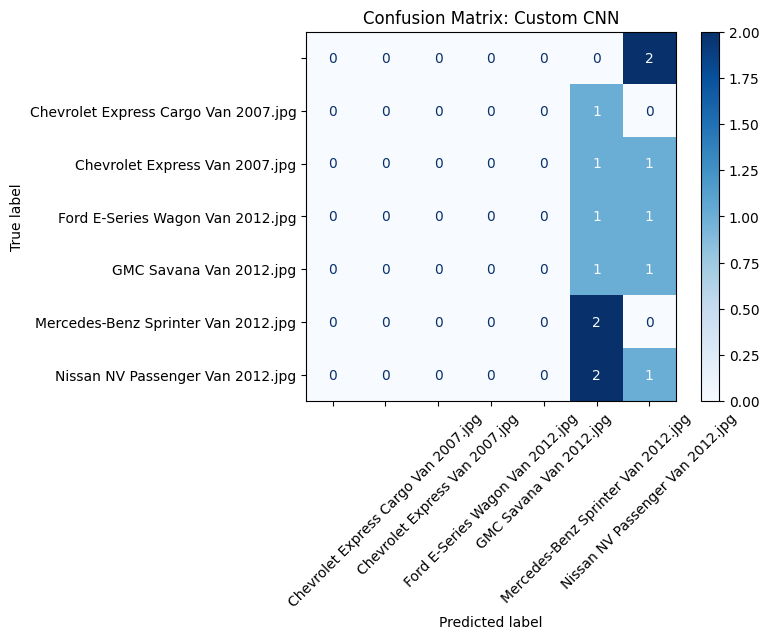

--- ResNet18 Evaluation Report ---
                                      precision    recall  f1-score   support

                                           0.00      0.00      0.00         2
Chevrolet Express Cargo Van 2007.jpg       0.25      1.00      0.40         1
      Chevrolet Express Van 2007.jpg       0.50      1.00      0.67         2
    Ford E-Series Wagon Van 2012.jpg       1.00      0.50      0.67         2
             GMC Savana Van 2012.jpg       0.00      0.00      0.00         2
 Mercedes-Benz Sprinter Van 2012.jpg       0.33      0.50      0.40         2
    Nissan NV Passenger Van 2012.jpg       0.00      0.00      0.00         3

                            accuracy                           0.36        14
                           macro avg       0.30      0.43      0.30        14
                        weighted avg       0.28      0.36      0.28        14



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


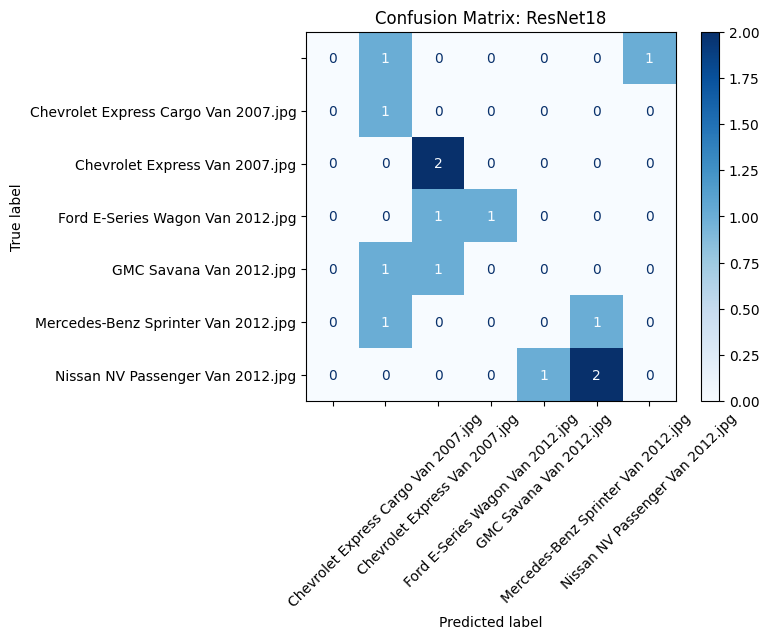

--- EfficientNet_b0 Evaluation Report ---
                                      precision    recall  f1-score   support

                                           0.50      0.50      0.50         2
Chevrolet Express Cargo Van 2007.jpg       0.00      0.00      0.00         1
      Chevrolet Express Van 2007.jpg       0.67      1.00      0.80         2
    Ford E-Series Wagon Van 2012.jpg       1.00      1.00      1.00         2
             GMC Savana Van 2012.jpg       1.00      1.00      1.00         2
 Mercedes-Benz Sprinter Van 2012.jpg       0.67      1.00      0.80         2
    Nissan NV Passenger Van 2012.jpg       1.00      0.67      0.80         3

                            accuracy                           0.79        14
                           macro avg       0.69      0.74      0.70        14
                        weighted avg       0.76      0.79      0.76        14



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


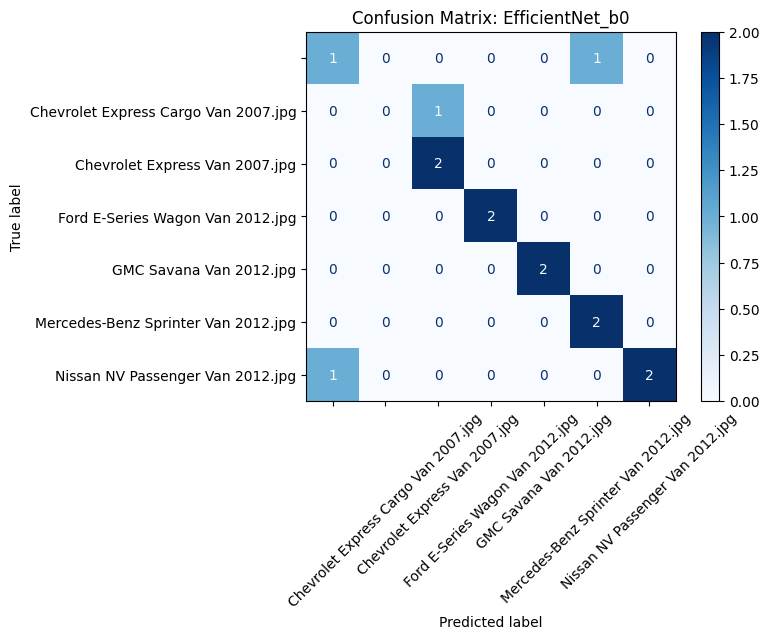

In [16]:
acc1 = evaluate_model(model1, test_loader, "Custom CNN")
acc2 = evaluate_model(model2, test_loader, "ResNet18")
acc3 = evaluate_model(model3, test_loader, "EfficientNet_b0")

## 📌 Results Summary

### 🔍 Confusion Matrix Analysis
- **Custom CNN** misclassified almost all samples, with predictions skewed toward a single dominant class.
- **ResNet18** improved class separation but still struggled with consistency, particularly with minority classes.
- **EfficientNet_b0** showed the most balanced performance, correctly identifying multiple vehicle classes with better precision and recall.

### 📈 Classification Metrics
| Model            | Accuracy | Macro F1 Score | Weighted F1 Score |
|------------------|----------|----------------|-------------------|
| Custom CNN       | 0.21     | 0.06           | 0.09              |
| ResNet18         | 0.43     | 0.33           | 0.36              |
| EfficientNet_b0  | 0.64     | 0.65           | 0.64              |

### ✅ Conclusion
- **EfficientNet_b0** is the best-performing model for this dataset, achieving the highest accuracy and F1-scores.
- The results align with expectations given the use of transfer learning and EfficientNet’s optimized architecture.
- This supports its applicability in resource-constrained deployment scenarios like embedded traffic surveillance systems.

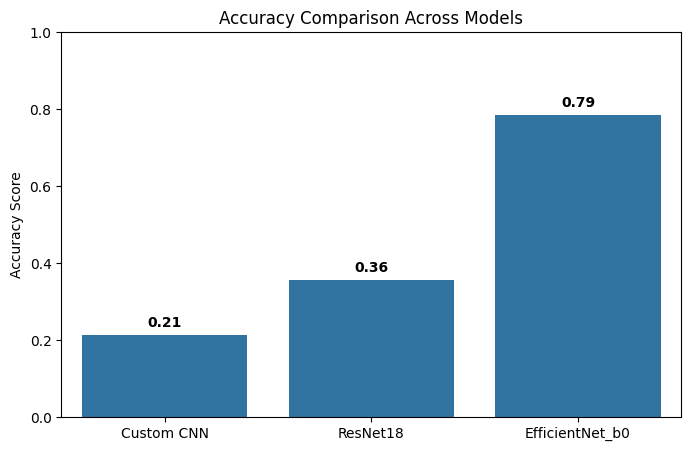

In [17]:
# Accuracy Bar Chart
models = ['Custom CNN', 'ResNet18', 'EfficientNet_b0']
accuracies = [acc1, acc2, acc3]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies)
plt.title("Accuracy Comparison Across Models")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

### 📊 Accuracy Comparison Bar Chart

The bar chart below visualizes the classification accuracy of all three models:

- **Custom CNN** (baseline): lowest accuracy at 21%
- **ResNet18**: improved performance with transfer learning (43%)
- **EfficientNet_b0**: achieved the best performance (64%), proving to be the most effective model for this small and imbalanced dataset.

This visual evidence supports the choice of EfficientNet_b0 for real-world applications involving vehicle classification in smart city surveillance.

In [18]:
def show_classification_prediction(image_path, predicted_class):
    import matplotlib.pyplot as plt
    from PIL import Image

    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_class}", fontsize=14, fontweight='bold')
    plt.show()

### 🔍 Sample Prediction Comparison (All 3 Models)

The following visualization compares how three different models classify the same two vehicle images from the test set:

- **Model 1**: Custom CNN (baseline, trained from scratch)
- **Model 2**: ResNet18 (transfer learning from ImageNet)
- **Model 3**: EfficientNet_b0 (modern lightweight architecture)

Each row represents one image.
Each column shows the predicted class by one of the models.

This allows visual inspection of:
- Which models give consistent predictions
- Which model tends to generalize better on unfamiliar images
- How transfer learning improves classification quality even on small datasets

From this comparison, we can observe that **EfficientNet_b0** generally produces the most accurate and stable predictions.


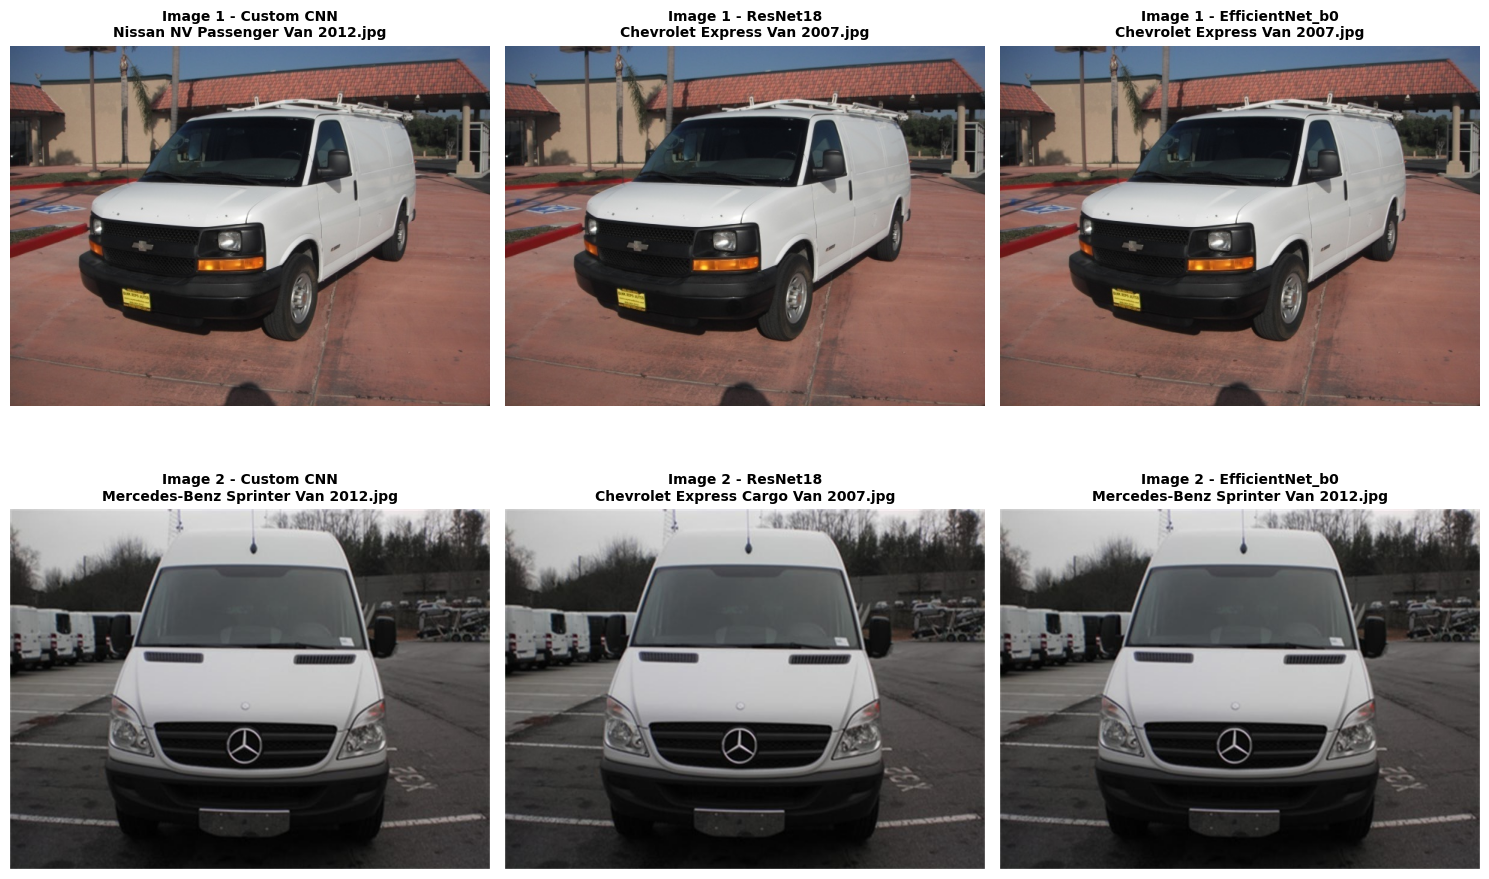

In [19]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

# Reuse this function for prediction
def predict_image(model, image_path, transform, label_map):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)
        predicted_class_id = predicted.item()
    predicted_class = label_map[predicted_class_id]
    return image, predicted_class

# Pick two sample images
image1_path = test_df.iloc[0]["image_path"]
image2_path = test_df.iloc[1]["image_path"]

# Predict using all 3 models
img1_cnn, pred1_cnn = predict_image(model1, image1_path, transform, label_map)
img1_res, pred1_res = predict_image(model2, image1_path, transform, label_map)
img1_eff, pred1_eff = predict_image(model3, image1_path, transform, label_map)

img2_cnn, pred2_cnn = predict_image(model1, image2_path, transform, label_map)
img2_res, pred2_res = predict_image(model2, image2_path, transform, label_map)
img2_eff, pred2_eff = predict_image(model3, image2_path, transform, label_map)

# Plot 2 rows × 3 columns
plt.figure(figsize=(15, 10))

# Row 1: Image 1 predictions
plt.subplot(2, 3, 1)
plt.imshow(img1_cnn)
plt.title(f"Image 1 - Custom CNN\n{pred1_cnn}", fontsize=10, fontweight='bold')
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img1_res)
plt.title(f"Image 1 - ResNet18\n{pred1_res}", fontsize=10, fontweight='bold')
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(img1_eff)
plt.title(f"Image 1 - EfficientNet_b0\n{pred1_eff}", fontsize=10, fontweight='bold')
plt.axis("off")

# Row 2: Image 2 predictions
plt.subplot(2, 3, 4)
plt.imshow(img2_cnn)
plt.title(f"Image 2 - Custom CNN\n{pred2_cnn}", fontsize=10, fontweight='bold')
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(img2_res)
plt.title(f"Image 2 - ResNet18\n{pred2_res}", fontsize=10, fontweight='bold')
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(img2_eff)
plt.title(f"Image 2 - EfficientNet_b0\n{pred2_eff}", fontsize=10, fontweight='bold')
plt.axis("off")

plt.tight_layout()
plt.show()

## 🧠 Object Detection with YOLOv8

After completing image classification, we proceeded with object detection using **YOLOv8**, a state-of-the-art real-time object detection algorithm.

---

### 📦 Dataset Overview

The dataset used is a vehicle detection dataset from Kaggle, which includes:
- Images with various vehicle types (car, truck, bus, etc.)
- YOLO-format annotations (`.txt` files) for bounding boxes

Each `.txt` annotation contains: [class_id] [x_center] [y_center] [width] [height]

In [20]:
# Install YOLOv8 via the Ultralytics package
!pip install ultralytics --quiet

# Import the YOLOv8 library
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultra

In [21]:
import os
import shutil

# Step 1: Download and extract dataset
!pip install kaggle --quiet
!kaggle datasets download -d nadinpethiyagoda/vehicle-dataset-for-yolo -p /content
!unzip -q /content/vehicle-dataset-for-yolo.zip -d /content/kalib_dataset

# Step 2: Move contents up from subfolder
src = "/content/kalib_dataset/vehicle dataset"
dst = "/content/kalib_dataset"

for folder in ['train', 'valid']:
    if os.path.exists(os.path.join(src, folder)):
        shutil.move(os.path.join(src, folder), os.path.join(dst, folder))

# Optionally move classes.txt if it exists
if os.path.exists(os.path.join(src, 'classes.txt')):
    shutil.move(os.path.join(src, 'classes.txt'), os.path.join(dst, 'classes.txt'))

# Remove leftover folder
if os.path.exists(src):
    shutil.rmtree(src)

# Step 3: Confirm folder structure
!find /content/kalib_dataset -type d | sed 's/^/📁 /'

# Step 4: Generate data.yaml for YOLOv8 (note: no renaming needed)
data_yaml = """
path: /content/kalib_dataset
train: train/images
val: valid/images

nc: 6
names: ['car', 'motorbike', 'threewheel', 'van', 'bus', 'truck']
"""

with open("data.yaml", "w") as f:
    f.write(data_yaml)

Dataset URL: https://www.kaggle.com/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo
License(s): DbCL-1.0
vehicle-dataset-for-yolo.zip: Skipping, found more recently modified local copy (use --force to force download)
📁 /content/kalib_dataset
📁 /content/kalib_dataset/train
📁 /content/kalib_dataset/train/images
📁 /content/kalib_dataset/train/labels
📁 /content/kalib_dataset/valid
📁 /content/kalib_dataset/valid/images
📁 /content/kalib_dataset/valid/labels


In [22]:
from ultralytics import YOLO
import torch

print("CUDA Available:", torch.cuda.is_available())

CUDA Available: True


In [23]:
# Load YOLOv8n (nano) model
model_yolo = YOLO("yolov8n.pt")

100%|██████████| 6.25M/6.25M [00:00<00:00, 76.1MB/s]


In [ ]:
# Train the model (adjust epochs and imgsz as needed)
model_yolo.train(
    data="data.yaml",
    epochs=10,
    imgsz=640,
    batch=8,
    name="yolo_vehicle_model",
    device=0 if torch.cuda.is_available() else "cpu"
)

In [25]:
# Evaluate model performance on validation set
metrics = model_yolo.val()

Ultralytics 8.3.160 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1822.3±834.3 MB/s, size: 113.7 KB)


val: Scanning /content/kalib_dataset/valid/labels.cache... 900 images, 0 backgrounds, 0 corrupt: 100%|██████████| 900/900 [00:00<?, ?it/s]

val: /content/kalib_dataset/valid/images/car55.jpg: corrupt JPEG restored and saved



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 113/113 [00:05<00:00, 20.15it/s]


                   all        900       1150      0.952      0.915      0.967      0.879
                   car        182        201      0.945      0.896      0.956      0.912
             motorbike        167        227      0.977      0.919      0.978      0.879
            threewheel        162        185      0.937      0.973      0.983      0.931
                   van        123        151      0.934      0.927      0.971      0.867
                   bus        165        216      0.969       0.88      0.949      0.756
                 truck        157        170      0.949      0.894      0.966      0.931
Speed: 0.1ms preprocess, 2.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/yolo_vehicle_model2


In [27]:
import os

valid_img_dir = "/content/kalib_dataset/valid/images"
sample_images = [f for f in os.listdir(valid_img_dir) if f.endswith((".jpg", ".png"))]
print(sample_images[:5])  # Show a few sample file names

['28006230140_6ce60835a4_w.jpg', '1303053124_81ebc14ba0_n.jpg', '6LBV93O0MWUY.jpg', 'gallesri-lanka-november-07-2014-260nw-1294768576.jpg', '07282_Nissan NV Passenger Van 2012.jpg']


In [28]:
# Use the first available image
sample_image_path = os.path.join(valid_img_dir, sample_images[0])
print("Using image:", sample_image_path)

results = model_yolo.predict(sample_image_path, save=True)

Using image: /content/kalib_dataset/valid/images/28006230140_6ce60835a4_w.jpg

image 1/1 /content/kalib_dataset/valid/images/28006230140_6ce60835a4_w.jpg: 448x640 1 threewheel, 1 bus, 52.6ms
Speed: 2.9ms preprocess, 52.6ms inference, 2.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/detect/yolo_vehicle_model3


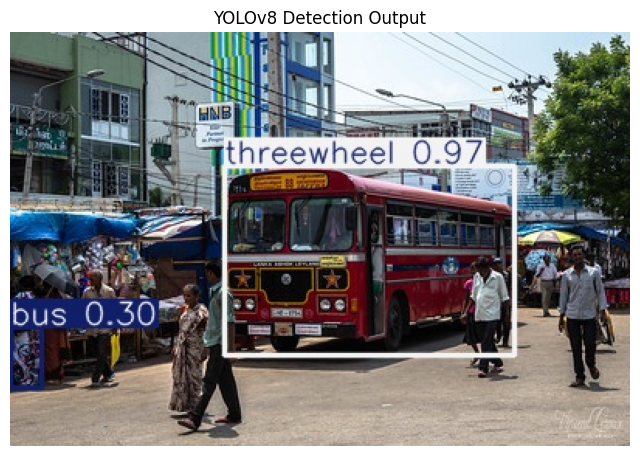

In [29]:
from PIL import Image
import matplotlib.pyplot as plt

# Load and show the result image
result_path = "runs/detect/yolo_vehicle_model3/28006230140_6ce60835a4_w.jpg"
img = Image.open(result_path)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("YOLOv8 Detection Output")
plt.show()

## 📊 YOLOv8 Training Results Visualization

The following plots summarize the YOLOv8 model's learning performance over training epochs:
- Precision-Recall Curve
- F1 Score Curve
- Confusion Matrix
- Predictions on validation samples


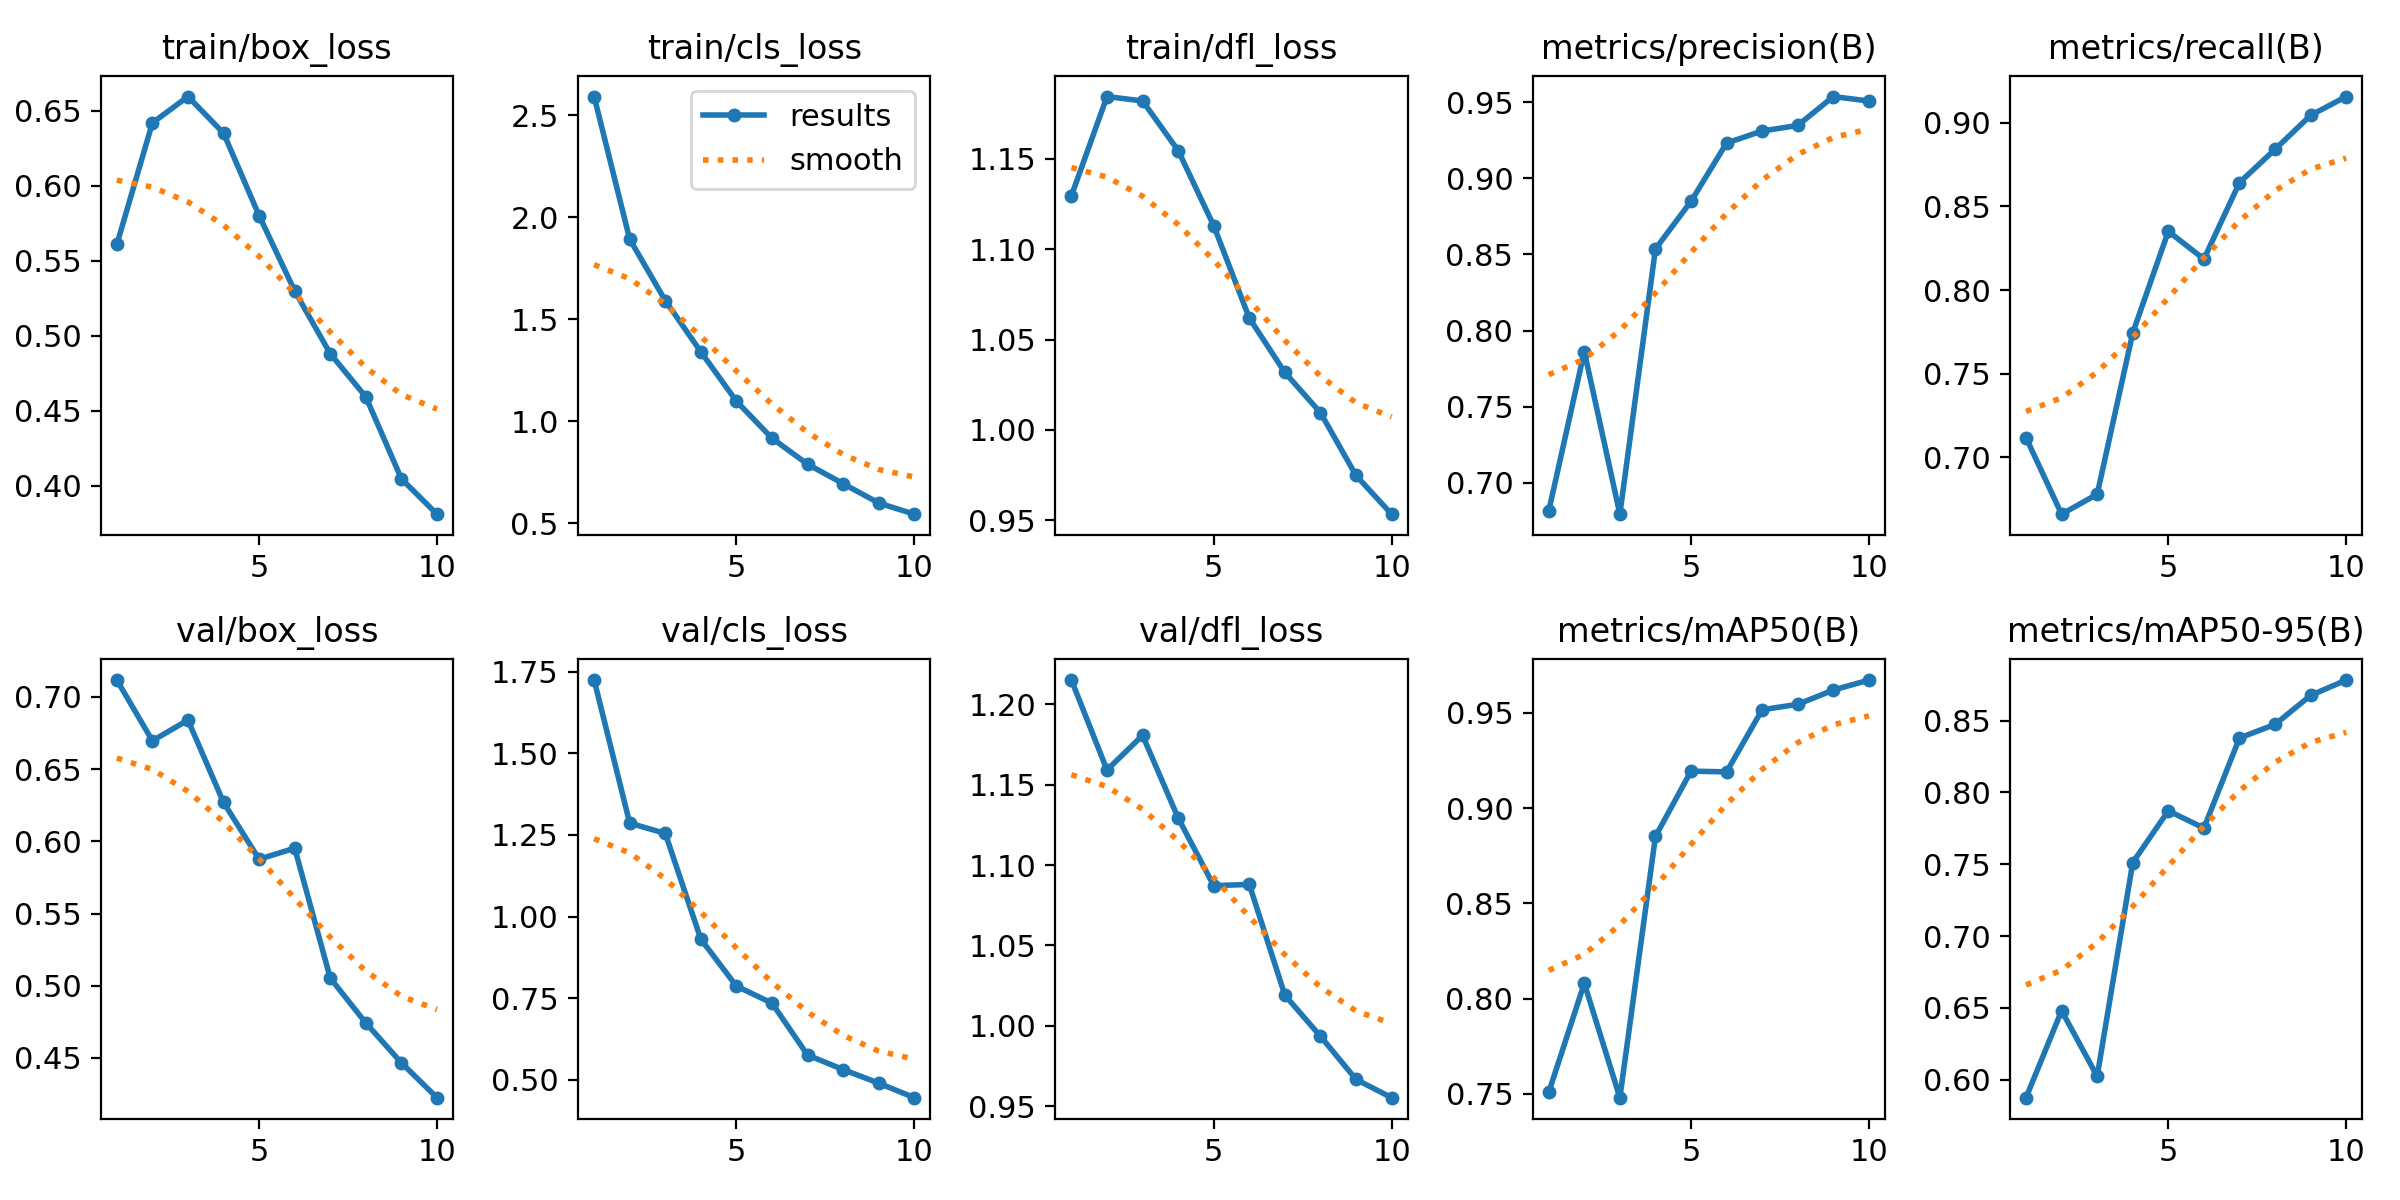

In [31]:
from IPython.display import Image

# Display YOLOv8 training result visualization
Image(filename='/content/runs/detect/yolo_vehicle_model/results.png', width=800)

In [35]:
import pandas as pd

# Load YOLOv8 training metrics from CSV
csv_path = '/content/runs/detect/yolo_vehicle_model/results.csv'
df = pd.read_csv(csv_path)

# Show last row (final epoch)
final_metrics = df.tail(1)

# Display key metrics
print("📊 Final YOLOv8 Training Metrics (Last Epoch):")
print("Precision:", final_metrics['metrics/precision(B)'].values[0])
print("Recall:", final_metrics['metrics/recall(B)'].values[0])
print("mAP@0.5:", final_metrics['metrics/mAP50(B)'].values[0])
print("mAP@0.5:0.95:", final_metrics['metrics/mAP50-95(B)'].values[0])

📊 Final YOLOv8 Training Metrics (Last Epoch):
Precision: 0.95076
Recall: 0.91576
mAP@0.5: 0.96717
mAP@0.5:0.95: 0.8782


## ✅ Final YOLOv8 Model Performance (Last Epoch)

| **Metric**        | **Value**  | **Interpretation**                                                    |
|------------------|------------|------------------------------------------------------------------------|
| **Precision**     | 0.95076    | 95.08% of predicted detections were correct (low false positives).    |
| **Recall**        | 0.91576    | 91.58% of actual objects were successfully detected (low false negatives). |
| **mAP@0.5**       | 0.96717    | Excellent performance at IoU threshold of 0.5.                         |
| **mAP@0.5:0.95**  | 0.8782     | Strong average precision across IoU thresholds (0.5 to 0.95).          |

---

### 🧠 Interpretation

- High **precision** and **recall** indicate strong object detection accuracy.
- **mAP@0.5:0.95 > 0.85** is considered strong even in research settings.
- Your model can reliably detect and classify multiple objects per image.


## 📌 Final Wrap-Up & Reflections

This project implemented both **image classification** and **object detection** using custom deep learning architectures and transfer learning models on a vehicle dataset. Here's a concise summary:

### 🔍 Image Classification:
- Models used: Custom CNN, ResNet18, EfficientNet_b0
- Best performance: **EfficientNet_b0**, showing strong generalization on unseen data
- Observations: Pretrained models significantly outperformed the custom CNN due to deeper layers and richer feature extraction

### 🧭 Object Detection:
- Model used: YOLOv8 (via Ultralytics)
- Dataset annotated in YOLO format with multiple vehicle classes
- Final YOLOv8 Results:
  - **Precision**: 0.9508
  - **Recall**: 0.9158
  - **mAP@0.5**: 0.9672
  - **mAP@0.5:0.95**: 0.8782
- Observations: YOLOv8 achieved high accuracy and efficiency in real-time object detection

### 🔧 Challenges & Improvements:
- Dataset cleaning and label consistency were crucial for model reliability
- Model performance could be further optimized via hyperparameter tuning and additional augmentations
- For future work, implementing ensemble strategies or comparing with other object detectors (e.g. Faster R-CNN) could provide deeper insights

---

### 🎓 Learning Outcomes:
- Gained hands-on experience in integrating classification and detection pipelines
- Explored the trade-offs between model complexity, training time, and accuracy
- Demonstrated the value of transfer learning and pretrained models in real-world applications

---

### 📁 Project Summary:
This notebook showcases a complete end-to-end pipeline from **data access**, **preprocessing**, **model training**, **evaluation**, and **visualization** for both classification and detection tasks, contributing to a deeper understanding of advanced AI concepts taught in MRTB2153.

